In [615]:
import numpy as np
import pandas as pd
from scipy import stats
from statsmodels.stats.multitest import multipletests
import statsmodels.formula.api as smf
from sklearn.preprocessing import StandardScaler
from scipy.spatial.distance import cdist
import torch
from torch import nn
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LassoCV, LogisticRegressionCV
import statsmodels.api as sm

In [3]:
df = pd.read_excel("wage_gap.xlsx")

# Задание 1

In [31]:
smsa_history = (
    df.groupby("n")[["SMSA_central"]]
    .agg(["min", "max", "first"])
    .reset_index()
)

smsa_history

n SMSA_central          
                     min max first
0        85            0   1     1
1        88            0   1     1
2       102            0   1     1
3       179            0   0     0
4       184            0   1     0
...     ...          ...  ..   ...
1716  12515            0   0     0
1717  12517            0   0     0
1718  12523            0   1     1
1719  12594            0   0     0
1720  12659            0   1     0

[1721 rows x 4 columns]

In [43]:
def ever_bact_to_zero(s):
    seen_one = False
    for i in s:
        if i == 1:
            seen_one = True
        if seen_one and i == 0:
            return True
    return False

never_central_ids = smsa_history[smsa_history["SMSA_central", "max"] == 0]["n"]
moved_to_central_ids = smsa_history[
    (smsa_history["SMSA_central", "min"] == 0) &
    (smsa_history["SMSA_central", "max"] == 1) &
    (smsa_history["SMSA_central", "first"] == 0)
    ]["n"]

back_to_0_ids = (
    df[df["n"].isin(moved_to_central_ids)]
    .groupby("n")["SMSA_central"]
    .apply(ever_bact_to_zero)
)

print(f"Число людей 0->1->0 в тритменте: {back_to_0_ids.sum()}")

Число людей 0->1->0 в тритменте: 0


In [44]:
covariates = ["fam_size", "AFQT2", "education", "HGT_father", "HGT_mother", "self_conf", "size_of_firm", "risk"]

idx_first_y = df.groupby("n")["t"].idxmin()
baseline_df = df.loc[idx_first_y].copy()

baseline_df[["cpi_w"] + covariates].isna().mean()

cpi_w           0.000000
fam_size        0.000000
AFQT2           0.029053
education       0.000000
HGT_father      0.163277
HGT_mother      0.058687
self_conf       0.026729
size_of_firm    0.027310
risk            0.059849
dtype: float64

In [45]:
baseline_df = baseline_df[baseline_df["n"].isin(never_central_ids) | baseline_df["n"].isin(moved_to_central_ids)]
baseline_df["treatment_group"] = np.where(
    baseline_df["n"].isin(moved_to_central_ids),
    1,
    0
)

n_treat = (baseline_df["treatment_group"] == 1).sum()
n_control = (baseline_df["treatment_group"] == 0).sum()

print(f"Число людей в тритмент: {n_treat}\nЧисло людей в контроле: {n_control}")

Число людей в тритмент: 72
Число людей в контроле: 1196


In [333]:
balance_table = (
    baseline_df
    .groupby("treatment_group")[needed_columns]
    .mean()
    .T
    .rename_axis(None, axis=1)
    .reset_index()
    .rename(columns={"index": "variable", 0: "Control", 1: "Treatment"})
)

X_control = baseline_df[baseline_df["treatment_group"] == 0][needed_columns].values
X_treat = baseline_df[baseline_df["treatment_group"] == 1][needed_columns].values

pvals_raw = stats.ttest_ind(
    X_control, 
    X_treat,
    equal_var=False,
    nan_policy = "omit").pvalue

reject, p_holm, _, _ = multipletests(pvals_raw, alpha=0.05, method="holm")

balance_table["P_value"] = pvals_raw
balance_table["P_value_Holm"] = p_holm
balance_table["Reject_equal_means"] = reject

balance_table

,variable,Control,Treatment,P_value,P_value_Holm,Reject_equal_means
0,fam_size,4.889632,4.652778,0.344287,0.988871,False
1,AFQT2,35.314163,39.691176,0.195158,0.975788,False
2,education,12.327181,13.541667,0.000033,0.000261,True
3,HGT_father,10.400396,11.228070,0.129494,0.776966,False
4,HGT_mother,10.482238,10.857143,0.310446,0.988871,False
5,self_conf,21.844635,22.352941,0.309422,0.988871,False
6,size_of_firm,3678.904145,6960.140845,0.247218,0.988871,False
7,risk,0.402428,0.541667,0.024825,0.173773,False


In [357]:
for cov in covariates:
    
    mean_t = baseline_df[baseline_df["treatment_group"] == 1][cov].mean()
    mean_c = baseline_df[baseline_df["treatment_group"] == 0][cov].mean()

    var_t = baseline_df[baseline_df["treatment_group"] == 1][cov].var(ddof=1)
    var_c = baseline_df[baseline_df["treatment_group"] == 0][cov].var(ddof=1)

    sd = np.sqrt(0.5 * (var_t + var_c))

    smd = (mean_t - mean_c) / sd
    print(f"SMD для {cov}: {std:.2f}")

SMD для fam_size: 0.06
SMD для AFQT2: 0.06
SMD для education: 0.06
SMD для HGT_father: 0.06
SMD для HGT_mother: 0.06
SMD для self_conf: 0.06
SMD для size_of_firm: 0.06
SMD для risk: 0.06


# Задание 2

In [65]:
panel_sample = df[df["n"].isin(moved_to_central_ids) | df["n"].isin(never_central_ids)].copy()

panel_sample["moved_to_central"] = np.where(
    panel_sample["n"].isin(moved_to_central_ids),
    1,
    0
)

idx_last_y = panel_sample.groupby("n")["t"].idxmax()
outcome_1994 = panel_sample.loc[idx_last_y].copy()

assert outcome_1994["n"].nunique() == outcome_1994.shape[0]

In [72]:
ols_pair_1994 = smf.ols("cpi_w ~ moved_to_central", data=outcome_1994).fit(cov_type="HC1")
ols_pair_1994.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  cpi_w   R-squared:                       0.007
Model:                            OLS   Adj. R-squared:                  0.006
Method:                 Least Squares   F-statistic:                     3.418
Date:                Thu, 11 Dec 2025   Prob (F-statistic):             0.0648
Time:                        14:54:11   Log-Likelihood:                -8884.3
No. Observations:                1100   AIC:                         1.777e+04
Df Residuals:                    1098   BIC:                         1.778e+04
Df Model:                           1                                         
Covariance Type:                  HC1                                         
====================================================================================
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept         1090.0039     23.184     47.015      0.000    1044.564    1135.444
moved_to_central   279.5899    151.236      1.849      0.065     -16.827     576.007
==============================================================================
Omnibus:                     1008.814   Durbin-Watson:                   1.815
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            40796.466
Skew:                           4.167   Prob(JB):                         0.00
Kurtosis:                      31.647   Cond. No.                         4.29
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC1)
"""

In [71]:
panel_sample_sorted = panel_sample.sort_values(["n", "t"]).copy()

panel_sample_sorted["cpi_w_ff"] = (
    panel_sample_sorted
    .groupby("n")["cpi_w"]
    .ffill()
)

idx_last_y = panel_sample_sorted.groupby("n")["t"].idxmax()
outcome_1994_ff = panel_sample_sorted.loc[idx_last_y].copy()

ols_pair_1994_ff = smf.ols("cpi_w_ff ~ moved_to_central", data=outcome_1994_ff).fit(cov_type="HC1")
ols_pair_1994_ff.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:               cpi_w_ff   R-squared:                       0.008
Model:                            OLS   Adj. R-squared:                  0.007
Method:                 Least Squares   F-statistic:                     4.469
Date:                Thu, 11 Dec 2025   Prob (F-statistic):             0.0347
Time:                        14:54:04   Log-Likelihood:                -10193.
No. Observations:                1268   AIC:                         2.039e+04
Df Residuals:                    1266   BIC:                         2.040e+04
Df Model:                           1                                         
Covariance Type:                  HC1                                         
====================================================================================
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept         1051.7180     20.789     50.591      0.000    1010.973    1092.463
moved_to_central   290.1738    137.258      2.114      0.035      21.154     559.194
==============================================================================
Omnibus:                     1162.643   Durbin-Watson:                   1.794
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            50674.041
Skew:                           4.169   Prob(JB):                         0.00
Kurtosis:                      32.826   Cond. No.                         4.34
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC1)
"""

In [74]:
pre_1994 = panel_sample_sorted[panel_sample_sorted["t"] < 1994].copy()

last_pre_1994 = (
    pre_1994
    .dropna(subset=["cpi_w"])
    .groupby("n")["cpi_w"]
    .last()
    .rename("last_cpi_w_before_1994")
)

outcome_1994_ml = pd.merge(
    outcome_1994,
    last_pre_1994,
    on="n",
    how="left"
)

In [83]:
features = [
    "last_cpi_w_before_1994", "woman",
    "fam_size", "AFQT2", 
    "education", "HGT_father", 
    "HGT_mother", "self_conf", 
    "size_of_firm", "risk",
    "years", "married",
    "region", "white"
]

In [115]:
def fit_group_rf(data, group):
    group_data = data[data["moved_to_central"] == group].copy()

    train = group_data.dropna(subset=["cpi_w"])
    X = train[features]
    y = train["cpi_w"]

    train_mask = X.notna().all(axis=1)
    X = X[train_mask]
    y = y[train_mask]
    feat_means = X.mean()

    print(X.shape[0])

    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

    rf = RandomForestRegressor(
        n_estimators=500,
        min_samples_split=8,
        random_state=42,
        n_jobs=-1
    )
    rf.fit(X_train, y_train)

    val_pred = rf.predict(X_val)
    r2 = r2_score(y_val, val_pred)
    rmse = mean_squared_error(y_val, val_pred, squared=False)
    print(f"Group {group}: R2={r2:2f}\nRMSE={rmse:.2f}")

    return rf, feat_means

In [116]:
rf_control, feat_means_control = fit_group_rf(outcome_1994_ml, group=0)
rf_treat, feat_means_treat = fit_group_rf(outcome_1994_ml, group=1)

796


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


Group 0: R2=0.567055
RMSE=316.88
42
Group 1: R2=0.724797
RMSE=244.48


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [117]:
outcome_1994_ml["cpi_w_ml"] = outcome_1994_ml["cpi_w"].copy()

group_models = {
    0: (rf_control, feat_means_control),
    1: (rf_treat, feat_means_treat)
}

for group, (rf_model, feat_means) in group_models.items():
    mask_missing = (
        (outcome_1994_ml["moved_to_central"] == group) &
        (outcome_1994_ml["cpi_w_ml"].isna())
    )
    X_missing = outcome_1994_ml.loc[mask_missing, features]
    X_missing_filled = X_missing.fillna(feat_means)

    preds = rf_model.predict(X_missing)
    
    outcome_1994_ml.loc[X_missing_filled.index, "cpi_w_ml"] = preds

In [118]:
ols_pair_ml = smf.ols("cpi_w_ml ~ moved_to_central", data=outcome_1994_ml).fit(cov_type="HC1")
ols_pair_ml.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:               cpi_w_ml   R-squared:                       0.007
Model:                            OLS   Adj. R-squared:                  0.007
Method:                 Least Squares   F-statistic:                     4.157
Date:                Thu, 11 Dec 2025   Prob (F-statistic):             0.0417
Time:                        16:06:32   Log-Likelihood:                -10181.
No. Observations:                1268   AIC:                         2.037e+04
Df Residuals:                    1266   BIC:                         2.038e+04
Df Model:                           1                                         
Covariance Type:                  HC1                                         
====================================================================================
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept         1067.2545     20.616     51.768      0.000    1026.848    1107.661
moved_to_central   276.1495    135.449      2.039      0.041      10.674     541.625
==============================================================================
Omnibus:                     1179.602   Durbin-Watson:                   1.792
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            53716.016
Skew:                           4.252   Prob(JB):                         0.00
Kurtosis:                      33.731   Cond. No.                         4.34
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC1)
"""

# Задание 3

In [737]:
baseline = panel_sample.sort_values(["n", "t"]).groupby("n").head(1)

idx_last_y = panel_sample.groupby("n")["t"].idxmax()
outcome_1994 = panel_sample.loc[idx_last_y].copy()

panel_sample_sorted = panel_sample.sort_values(["n", "t"]).copy()

panel_sample_sorted[covariates] = (
    panel_sample_sorted
    .groupby("n")[covariates]
    .ffill()
)

last_pre_move = (
    panel_sample_sorted[panel_sample_sorted["moved_to_central"] == 1]
    .query("SMSA_central == 0")
    .groupby("n")
    .last()
)

last_never_move = (
    panel_sample_sorted[panel_sample_sorted["moved_to_central"] == 0]
    .groupby("n")
    .last()
)

baseline_for_matching = pd.concat([last_pre_move, last_never_move], ignore_index=False).dropna(subset=covariates)
baseline_for_matching_raw = baseline_for_matching.copy()


scaler = StandardScaler()

X_scaled = scaler.fit_transform(baseline_for_matching[covariates_for_matching])

X_scaled_df = pd.DataFrame(
    X_scaled,
    index=baseline_for_matching.index,
    columns=covariates_for_matching
)

X_scaled_df["moved_to_central"] = baseline_for_matching["moved_to_central"].copy()

treated_cov = X_scaled_df[X_scaled_df["moved_to_central"] == 1].drop(columns=["moved_to_central"])
control_cov = X_scaled_df[X_scaled_df["moved_to_central"] == 0].drop(columns=["moved_to_central"])

treated_ids = treated_cov.index.to_numpy()
control_ids = control_cov.index.to_numpy()

X_treat = treated_cov.values
X_control = control_cov.values

cov_mat = cov_mat = np.cov(X_scaled_df[covariates_for_matching].values, rowvar=False)
cov_mat_inv = np.linalg.inv(cov_mat)

dist_mat = cdist(X_treat, X_control, metric="mahalanobis", VI=cov_mat_inv)

used_controls = set()

pairs_no_rep = []
pairs_with_rep = []

for i, treat_id in enumerate(treated_ids):
    distances = dist_mat[i, :]
    control_order = np.argsort(distances)

    best_control_id = control_ids[control_order[0]]
    best_distance = distances[control_order[0]]
    pairs_with_rep.append([treat_id, best_control_id, best_distance])

    chosen_control = None
    chosen_distance = None

    for j in control_order:
        candidate_id = control_ids[j]
        if candidate_id not in used_controls:
            chosen_control = candidate_id
            chosen_distance = distances[j]
            used_controls.add(candidate_id)
            break

    if chosen_control is not None:
        pairs_no_rep.append([treat_id, chosen_control, chosen_distance])

match_no_rep = pd.DataFrame(
    pairs_no_rep,
    columns=["treatment_id", "control_id", "distance"]
)

match_with_rep = pd.DataFrame(
    pairs_with_rep,
    columns=["treatment_id", "control_id", "distance"]
)

matches = match_no_rep.copy()

print(f"Без повторений:\n   Уникальных пар: {match_no_rep["control_id"].nunique()}\n   Минимальное расстояние: {match_no_rep["distance"].min():.2f}\n   Максимальное расстояние: {match_no_rep["distance"].max():.2f}")
print(f"Без с повторениями:\n   Уникальных пар: {match_no_rep["control_id"].nunique()}\n   Минимальное расстояние: {match_with_rep["distance"].min():.2f}\n   Максимальное расстояние: {match_with_rep["distance"].max():.2f}")

treatment_panel = panel_sample[panel_sample["n"].isin(matches["treatment_id"])][["n", "t", "cpi_w", "SMSA_central"]].copy()
treatment_panel = treatment_panel[treatment_panel["SMSA_central"] == 1]

treatment_panel = pd.merge(
    treatment_panel,
    matches[["treatment_id", "control_id"]],
    left_on="n",
    right_on="treatment_id",
    how="left"
).drop(columns=["treatment_id"])

control_panel = panel_sample[panel_sample["n"].isin(matches["control_id"])][["n", "t", "cpi_w"]].rename(columns={"n": "control_id"}).copy()

att_pairs = pd.merge(
    treatment_panel,
    control_panel,
    on=["control_id", "t"],
    how="left",
    suffixes=["_treatment", "_control"]
).dropna(subset=["cpi_w_treatment", "cpi_w_control"])

att = (att_pairs["cpi_w_treatment"] - att_pairs["cpi_w_control"]).mean()

print(f"Значение ATT: {att:.2f}")

Без повторений:
   Уникальных пар: 49
   Минимальное расстояние: 0.26
   Максимальное расстояние: 2.78
Без с повторениями:
   Уникальных пар: 49
   Минимальное расстояние: 0.26
   Максимальное расстояние: 2.78
Значение ATT: 232.93


In [738]:
diff = att_pairs["cpi_w_treatment"] - att_pairs["cpi_w_control"]
att = diff.mean()
se = diff.std(ddof=1) / np.sqrt(len(diff))
t_stat = att / se
p_val = 2 * (1 - stats.t.cdf(np.abs(t_stat), df=len(diff)-1))

att, se, t_stat, p_val

(232.93022282788206,
 38.75386188398242,
 6.010503508662082,
 5.542749148546022e-09)

In [739]:
np.random.seed(2004)

att_pairs = att_pairs.assign(
    pair_ids = att_pairs.groupby(["n", "control_id"]).ngroup()
)

att = diff.mean()
att_se  = diff.std(ddof=1) / np.sqrt(len(diff))

pairs_ids = att_pairs["pair_ids"]
att_pairs["diff"] = att_pairs["cpi_w_treatment"] - att_pairs["cpi_w_control"]
B = 10000
att_boot_efron = []
t_b = []

for b in range(B):
    
    sampled_pairs = np.random.choice(pairs_ids, size=len(pairs_ids), replace=True)
    sample = att_pairs[att_pairs["pair_ids"].isin(sampled_pairs)]
    diff_b = sample["diff"]
    
    att_b = diff_b.mean()
    att_b_se = diff_b.std(ddof=1) / np.sqrt(len(diff_b))
    t = (att_b - att) / att_b_se
    
    att_boot_efron.append(diff_b.mean())
    t_b.append(t)

CI_efron = np.percentile(att_boot_efron, [2.5, 97.5])

t_lower, t_upper  = np.percentile(t_b, [2.5, 97.5])
CI_t_percentile = [att - att_se * t_upper, att - att_se * t_lower]

print(f"ДИ по Эфрону: {CI_efron}\nДИ t-перцентильный: {CI_t_percentile}") 

ДИ по Эфрону: [224.11916293 242.13152135]
ДИ t-перцентильный: [223.869673433068, 241.61390119186154]


In [740]:
matched_ids = pd.concat([matches["treatment_id"], matches["control_id"]], ignore_index=True).unique()
matched_outcome_1994 = outcome_1994[outcome_1994["n"].isin(matched_ids)].dropna(subset=["cpi_w"]).copy()

ols_matches = smf.ols("cpi_w ~ moved_to_central", data=matched_outcome_1994).fit(cov_type="HC1")
ols_matches.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  cpi_w   R-squared:                       0.014
Model:                            OLS   Adj. R-squared:                  0.002
Method:                 Least Squares   F-statistic:                     1.198
Date:                Sun, 14 Dec 2025   Prob (F-statistic):              0.277
Time:                        20:53:29   Log-Likelihood:                -695.36
No. Observations:                  88   AIC:                             1395.
Df Residuals:                      86   BIC:                             1400.
Df Model:                           1                                         
Covariance Type:                  HC1                                         
====================================================================================
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept         1184.5333    112.902     10.492      0.000     963.250    1405.817
moved_to_central   153.2806    140.030      1.095      0.274    -121.174     427.735
==============================================================================
Omnibus:                       71.140   Durbin-Watson:                   1.850
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              563.313
Skew:                           2.428   Prob(JB):                    4.77e-123
Kurtosis:                      14.404   Cond. No.                         2.59
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC1)
"""

# Задача 4

In [463]:
def make_balance_table(baseline_df, covariates):
    balance_table = (
        baseline_df
        .groupby("moved_to_central")[covariates]
        .mean()
        .T
        .rename_axis(None, axis=1)
        .reset_index()
        .rename(columns={"index": "variable", 0: "Control", 1: "Treatment"})
    )
    
    X_control = baseline_df[baseline_df["moved_to_central"] == 0][covariates].values
    X_treat = baseline_df[baseline_df["moved_to_central"] == 1][covariates].values
    
    pvals_raw = stats.ttest_ind(
        X_control, 
        X_treat,
        equal_var=False,
        nan_policy = "omit").pvalue
    
    reject, p_holm, _, _ = multipletests(pvals_raw, alpha=0.05, method="holm")
    
    balance_table["P_value"] = pvals_raw
    balance_table["P_value_Holm"] = p_holm
    balance_table["Reject_equal_means"] = reject

    SMD = []
    
    for cov in covariates:
        
        mean_t = baseline_df[baseline_df["moved_to_central"] == 1][cov].mean()
        mean_c = baseline_df[baseline_df["moved_to_central"] == 0][cov].mean()

        var_t = baseline_df[baseline_df["moved_to_central"] == 1][cov].var(ddof=1)
        var_c = baseline_df[baseline_df["moved_to_central"] == 0][cov].var(ddof=1)

        sd = np.sqrt(0.5 * (var_t + var_c))
    
        smd = (mean_t - mean_c) / sd
        
        SMD.append(smd)

    balance_table["SMD"] = SMD
    
    return balance_table

baseline_for_cov_table = baseline_for_matching.loc[baseline_for_matching.index.isin(matched_ids)].copy()

pd.set_option('display.width', 120)
print(make_balance_table(baseline_raw, covariates))
pd.reset_option("display.width")

       variable      Control    Treatment   P_value  P_value_Holm  Reject_equal_means       SMD
0      fam_size     2.916667     2.722222  0.466146           1.0               False -0.121792
1         AFQT2    38.225352    39.691176  0.741051           1.0               False  0.056225
2     education    13.277778    13.541667  0.470002           1.0               False  0.120739
3    HGT_father    10.870968    11.228070  0.623856           1.0               False  0.090249
4    HGT_mother    10.750000    10.857143  0.827905           1.0               False  0.037068
5     self_conf    22.542857    22.352941  0.774746           1.0               False -0.048841
6  size_of_firm  6019.112676  6960.140845  0.809488           1.0               False  0.040540
7          risk     0.549296     0.541667  0.927647           1.0               False -0.015215


# Задание 3 (Варианты с заполнением пропусков)

In [742]:
baseline = panel_sample.sort_values(["n", "t"]).groupby("n").head(1)

idx_last_y = panel_sample.groupby("n")["t"].idxmax()
outcome_1994 = panel_sample.loc[idx_last_y].copy()

panel_sample_sorted = panel_sample.sort_values(["n", "t"]).copy()

panel_sample_sorted[covariates] = (
    panel_sample_sorted
    .groupby("n")[covariates]
    .ffill()
)

last_pre_move = (
    panel_sample_sorted[panel_sample_sorted["moved_to_central"] == 1]
    .query("SMSA_central == 0")
    .groupby("n")
    .last()
)

last_never_move = (
    panel_sample_sorted[panel_sample_sorted["moved_to_central"] == 0]
    .groupby("n")
    .last()
)

baseline_for_matching = pd.concat([last_pre_move, last_never_move], ignore_index=False)
baseline_for_matching[covariates + ["cpi_w"]][baseline_for_matching["moved_to_central"] == 1].isna().mean()

fam_size        0.000000
AFQT2           0.055556
education       0.000000
HGT_father      0.208333
HGT_mother      0.027778
self_conf       0.055556
size_of_firm    0.013889
risk            0.000000
cpi_w           0.000000
dtype: float64

In [743]:
covariates_for_matching = ["fam_size", "AFQT2", "education", "HGT_mother", "self_conf", "size_of_firm", "risk"]

for cov in covariates_for_matching:
    for g in [0, 1]:
        mask_group = baseline_for_matching["moved_to_central"] == g
        group_mean = baseline_for_matching.loc[mask_group, cov].mean()
        baseline_for_matching.loc[mask_group & baseline_for_matching[cov].isna(), cov] = group_mean

baseline_for_matching[covariates_for_matching].info()

<class 'pandas.core.frame.DataFrame'>
Index: 1268 entries, 184 to 12594
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   fam_size      1268 non-null   float64
 1   AFQT2         1268 non-null   float64
 2   education     1268 non-null   float64
 3   HGT_mother    1268 non-null   float64
 4   self_conf     1268 non-null   float64
 5   size_of_firm  1268 non-null   float64
 6   risk          1268 non-null   float64
dtypes: float64(7)
memory usage: 79.2 KB


In [744]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(baseline_for_matching[covariates_for_matching])

X_scaled_df = pd.DataFrame(
    X_scaled,
    index=baseline_for_matching.index,
    columns=covariates_for_matching
)

X_scaled_df["moved_to_central"] = baseline_for_matching["moved_to_central"].copy()

In [745]:
treated_cov = X_scaled_df[X_scaled_df["moved_to_central"] == 1].drop(columns=["moved_to_central"])
control_cov = X_scaled_df[X_scaled_df["moved_to_central"] == 0].drop(columns=["moved_to_central"])

treated_ids = treated_cov.index.to_numpy()
control_ids = control_cov.index.to_numpy()

X_treat = treated_cov.values
X_control = control_cov.values

cov_mat = cov_mat = np.cov(X_scaled_df[covariates_for_matching].values, rowvar=False)
cov_mat_inv = np.linalg.inv(cov_mat)

dist_mat = cdist(X_treat, X_control, metric="mahalanobis", VI=cov_mat_inv)

In [746]:
used_controls = set()

pairs_no_rep = []
pairs_with_rep = []

for i, treat_id in enumerate(treated_ids):
    distances = dist_mat[i, :]
    control_order = np.argsort(distances)

    best_control_id = control_ids[control_order[0]]
    best_distance = distances[control_order[0]]
    pairs_with_rep.append([treat_id, best_control_id, best_distance])

    chosen_control = None
    chosen_distance = None

    for j in control_order:
        candidate_id = control_ids[j]
        if candidate_id not in used_controls:
            chosen_control = candidate_id
            chosen_distance = distances[j]
            used_controls.add(candidate_id)
            break

    if chosen_control is not None:
        pairs_no_rep.append([treat_id, chosen_control, chosen_distance])

match_no_rep = pd.DataFrame(
    pairs_no_rep,
    columns=["treatment_id", "control_id", "distance"]
)

match_with_rep = pd.DataFrame(
    pairs_with_rep,
    columns=["treatment_id", "control_id", "distance"]
)

matches = match_no_rep.copy()

In [747]:
print(f"Без повторений:\n   Уникальных пар: {match_no_rep["control_id"].nunique()}\n   Минимальное расстояние: {match_no_rep["distance"].min():.2f}\n   Максимальное расстояние: {match_no_rep["distance"].max():.2f}")
print(f"Без с повторениями:\n   Уникальных пар: {match_no_rep["control_id"].nunique()}\n   Минимальное расстояние: {match_with_rep["distance"].min():.2f}\n   Максимальное расстояние: {match_with_rep["distance"].max():.2f}")

Без повторений:
   Уникальных пар: 72
   Минимальное расстояние: 0.24
   Максимальное расстояние: 2.79
Без с повторениями:
   Уникальных пар: 72
   Минимальное расстояние: 0.24
   Максимальное расстояние: 2.79


In [748]:
matches

,treatment_id,control_id,distance
0,184,5515,0.262088
1,231,1905,0.451152
2,483,11887,0.899602
3,847,5622,0.779361
4,850,3124,0.804707
...,...,...,...
67,9955,10199,1.171147
68,10035,8688,2.794579
69,11007,1740,0.602672
70,11565,3019,0.666757


In [749]:
treatment_panel = panel_sample[panel_sample["n"].isin(matches["treatment_id"])][["n", "t", "cpi_w", "SMSA_central"]].copy()
treatment_panel = treatment_panel[treatment_panel["SMSA_central"] == 1]

treatment_panel = pd.merge(
    treatment_panel,
    matches[["treatment_id", "control_id"]],
    left_on="n",
    right_on="treatment_id",
    how="left"
).drop(columns=["treatment_id"])

control_panel = panel_sample[panel_sample["n"].isin(matches["control_id"])][["n", "t", "cpi_w"]].rename(columns={"n": "control_id"}).copy()

att_pairs = pd.merge(
    treatment_panel,
    control_panel,
    on=["control_id", "t"],
    how="left",
    suffixes=["_treatment", "_control"]
).dropna(subset=["cpi_w_treatment", "cpi_w_control"])

att = (att_pairs["cpi_w_treatment"] - att_pairs["cpi_w_control"]).mean()

print(f"Значение ATT: {att:.2f}")

Значение ATT: 125.55


In [750]:
diff = att_pairs["cpi_w_treatment"] - att_pairs["cpi_w_control"]
att = diff.mean()
se = diff.std(ddof=1) / np.sqrt(len(diff))
t_stat = att / se
p_val = 2 * (1 - stats.t.cdf(np.abs(t_stat), df=len(diff)-1))

att, se, t_stat, p_val

(125.55377151873687,
 47.205877721030234,
 2.659706324299582,
 0.008113787685061213)

In [751]:
np.random.seed(2004)

att_pairs = att_pairs.assign(
    pair_ids = att_pairs.groupby(["n", "control_id"]).ngroup()
)

att = diff.mean()
att_se  = diff.std(ddof=1) / np.sqrt(len(diff))

pairs_ids = att_pairs["pair_ids"]
att_pairs["diff"] = att_pairs["cpi_w_treatment"] - att_pairs["cpi_w_control"]
B = 10000
att_boot_efron = []
t_b = []

for b in range(B):
    
    sampled_pairs = np.random.choice(pairs_ids, size=len(pairs_ids), replace=True)
    sample = att_pairs[att_pairs["pair_ids"].isin(sampled_pairs)]
    diff_b = sample["diff"]
    
    att_b = diff_b.mean()
    att_b_se = diff_b.std(ddof=1) / np.sqrt(len(diff_b))
    t = (att_b - att) / att_b_se
    
    att_boot_efron.append(diff_b.mean())
    t_b.append(t)

CI_efron = np.percentile(att_boot_efron, [2.5, 97.5])

t_lower, t_upper  = np.percentile(t_b, [2.5, 97.5])
CI_t_percentile = [att - att_se * t_upper, att - att_se * t_lower]

print(f"ДИ по Эфрону: {CI_efron}\nДИ t-перцентильный: {CI_t_percentile}") 

ДИ по Эфрону: [114.98730172 131.75481364]
ДИ t-перцентильный: [119.47504911594193, 135.96929727633193]


In [752]:
att_pairs_ff = pd.merge(
    treatment_panel,
    control_panel,
    on=["control_id", "t"],
    how="left",
    suffixes=["_treatment", "_control"]
)

att_pairs_ff["cpi_w_treatment"] = (
    att_pairs_ff
    .groupby("n")["cpi_w_treatment"]
    .ffill()
)

att_pairs_ff["cpi_w_control"] = (
    att_pairs_ff
    .groupby("control_id")["cpi_w_control"]
    .ffill()
)

att_pairs_ff = att_pairs_ff.dropna(subset=["cpi_w_treatment", "cpi_w_control"]).copy()

In [753]:
att_ff = (att_pairs_ff["cpi_w_treatment"] - att_pairs_ff["cpi_w_control"]).mean()

diff_ff = att_pairs_ff["cpi_w_treatment"] - att_pairs_ff["cpi_w_control"]
att_ff = dif_ff.mean()
se_ff = dif_ff.std(ddof=1) / np.sqrt(len(dif_ff))
t_stat_ff = att_ff / se_ff
p_val = 2 * (1 - stats.t.cdf(np.abs(t_stat_ff), df=len(diff)-1))


np.random.seed(2004)

att_pairs_ff = att_pairs_ff.assign(
    pair_ids_ff = att_pairs_ff.groupby(["n", "control_id"]).ngroup()
)

att_ff = dif_ff.mean()
att_se_ff  = diff_ff.std(ddof=1) / np.sqrt(len(diff_ff))

pairs_ids_ff = att_pairs_ff["pair_ids_ff"]
att_pairs_ff["diff_ff"] = att_pairs_ff["cpi_w_treatment"] - att_pairs_ff["cpi_w_control"]
B = 10000
att_boot_efron_ff = []
t_b_ff = []

for b in range(B):
    
    sampled_pairs = np.random.choice(pairs_ids_ff, size=len(pairs_ids_ff), replace=True)
    sample = att_pairs_ff[att_pairs_ff["pair_ids_ff"].isin(sampled_pairs)]
    diff_b = sample["diff_ff"]
    
    att_b = diff_b.mean()
    att_b_se = diff_b.std(ddof=1) / np.sqrt(len(diff_b))
    t = (att_b - att_ff) / att_b_se
    
    att_boot_efron_ff.append(diff_b.mean())
    t_b_ff.append(t)

CI_efron_ff = np.percentile(att_boot_efron_ff, [2.5, 97.5])

t_lower_ff, t_upper_ff  = np.percentile(t_b_ff, [2.5, 97.5])
CI_t_percentile_ff = [att_ff - att_se_ff * t_upper_ff, att_ff - att_se_ff * t_lower_ff]

print(f"Значение ATT: {att_ff:.2f}")
print(se, t_stat, p_val)
print(f"ДИ по Эфрону: {CI_efron_ff}\nДИ t-перцентильный: {CI_t_percentile_ff}") 

Значение ATT: 136.32
47.205877721030234 2.659706324299582 0.0012604934415867408
ДИ по Эфрону: [127.91456318 141.19902943]
ДИ t-перцентильный: [131.5206472103031, 144.63703385008998]


In [754]:
matched_ids = pd.concat([matches["treatment_id"], matches["control_id"]], ignore_index=True).unique()
matched_outcome_1994 = outcome_1994_ff[outcome_1994_ff["n"].isin(matched_ids)].copy()

ols_matches = smf.ols("cpi_w ~ moved_to_central", data=matched_outcome_1994).fit(cov_type="HC1")
ols_matches.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  cpi_w   R-squared:                       0.017
Model:                            OLS   Adj. R-squared:                  0.009
Method:                 Least Squares   F-statistic:                     2.179
Date:                Sun, 14 Dec 2025   Prob (F-statistic):              0.142
Time:                        21:21:07   Log-Likelihood:                -1050.7
No. Observations:                 127   AIC:                             2105.
Df Residuals:                     125   BIC:                             2111.
Df Model:                           1                                         
Covariance Type:                  HC1                                         
====================================================================================
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept         1120.5079     76.347     14.677      0.000     970.871    1270.145
moved_to_central   249.0858    168.760      1.476      0.140     -81.677     579.848
==============================================================================
Omnibus:                      186.608   Durbin-Watson:                   2.111
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            12356.053
Skew:                           5.671   Prob(JB):                         0.00
Kurtosis:                      49.972   Cond. No.                         2.63
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC1)
"""

In [755]:
panel_sample_sorted = panel_sample.sort_values(["n", "t"]).copy()

panel_sample_sorted["cpi_w_ffill"] = (
    panel_sample_sorted
    .groupby("n")["cpi_w"]
    .ffill()
)

idx_last_y = panel_sample_sorted.groupby("n")["t"].idxmax()
outcome_1994_ff = panel_sample_sorted.loc[idx_last_y].copy()
outcome_1994_ff = outcome_1994_ff.dropna(subset=["cpi_w_ffill"])
matched_outcome_1994_ff = outcome_1994_ff[outcome_1994_ff["n"].isin(matched_ids)].copy()

ols_matches_ff = smf.ols("cpi_w_ffill ~ moved_to_central", data=matched_outcome_1994_ff).fit(cov_type="HC1")
ols_matches_ff.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            cpi_w_ffill   R-squared:                       0.017
Model:                            OLS   Adj. R-squared:                  0.010
Method:                 Least Squares   F-statistic:                     2.440
Date:                Sun, 14 Dec 2025   Prob (F-statistic):              0.121
Time:                        21:21:12   Log-Likelihood:                -1186.4
No. Observations:                 144   AIC:                             2377.
Df Residuals:                     142   BIC:                             2383.
Df Model:                           1                                         
Covariance Type:                  HC1                                         
====================================================================================
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept         1101.7082     70.758     15.570      0.000     963.024    1240.392
moved_to_central   240.1836    153.766      1.562      0.118     -61.193     541.560
==============================================================================
Omnibus:                      205.038   Durbin-Watson:                   2.042
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            14707.649
Skew:                           5.631   Prob(JB):                         0.00
Kurtosis:                      51.213   Cond. No.                         2.62
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC1)
"""

In [756]:
formula = "cpi_w_ffill ~ moved_to_central + " + " + ".join(covariates_for_matching)

ols_match_adj = smf.ols(
    formula,
    data=matched_outcome_1994_ff  # та же выборка 144 наблюдения
).fit(cov_type="HC1")

ols_match_adj.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            cpi_w_ffill   R-squared:                       0.286
Model:                            OLS   Adj. R-squared:                  0.237
Method:                 Least Squares   F-statistic:                     6.617
Date:                Sun, 14 Dec 2025   Prob (F-statistic):           4.11e-07
Time:                        21:22:03   Log-Likelihood:                -952.33
No. Observations:                 126   AIC:                             1923.
Df Residuals:                     117   BIC:                             1948.
Df Model:                           8                                         
Covariance Type:                  HC1                                         
====================================================================================
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept         -484.0548    413.534     -1.171      0.242   -1294.567     326.457
moved_to_central   140.0190     86.513      1.618      0.106     -29.543     309.581
fam_size            -7.0387     31.160     -0.226      0.821     -68.110      54.033
AFQT2                4.9219      2.210      2.227      0.026       0.590       9.254
education           46.8536     26.924      1.740      0.082      -5.916      99.623
HGT_mother          10.4880     19.139      0.548      0.584     -27.023      47.999
self_conf           30.0082     14.249      2.106      0.035       2.081      57.935
size_of_firm        -0.0013      0.002     -0.814      0.416      -0.005       0.002
risk               -56.9613     93.920     -0.606      0.544    -241.041     127.118
==============================================================================
Omnibus:                        3.834   Durbin-Watson:                   1.815
Prob(Omnibus):                  0.147   Jarque-Bera (JB):                3.258
Skew:                           0.336   Prob(JB):                        0.196
Kurtosis:                       3.412   Cond. No.                     2.25e+05
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC1)
[2] The condition number is large, 2.25e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

# Задние 4 (Для вариантов с заполнением пропусков)

In [479]:
def make_balance_table(baseline_df, covariates):
    balance_table = (
        baseline_df
        .groupby("moved_to_central")[covariates]
        .mean()
        .T
        .rename_axis(None, axis=1)
        .reset_index()
        .rename(columns={"index": "variable", 0: "Control", 1: "Treatment"})
    )
    
    X_control = baseline_df[baseline_df["moved_to_central"] == 0][covariates].values
    X_treat = baseline_df[baseline_df["moved_to_central"] == 1][covariates].values
    
    pvals_raw = stats.ttest_ind(
        X_control, 
        X_treat,
        equal_var=False,
        nan_policy = "omit").pvalue
    
    reject, p_holm, _, _ = multipletests(pvals_raw, alpha=0.05, method="holm")
    
    balance_table["P_value"] = pvals_raw
    balance_table["P_value_Holm"] = p_holm
    balance_table["Reject_equal_means"] = reject

    SMD = []
    
    for cov in covariates:
        
        mean_t = baseline_df[baseline_df["moved_to_central"] == 1][cov].mean()
        mean_c = baseline_df[baseline_df["moved_to_central"] == 0][cov].mean()

        var_t = baseline_df[baseline_df["moved_to_central"] == 1][cov].var(ddof=1)
        var_c = baseline_df[baseline_df["moved_to_central"] == 0][cov].var(ddof=1)

        sd = np.sqrt(0.5 * (var_t + var_c))
    
        smd = (mean_t - mean_c) / sd
        
        SMD.append(smd)

    balance_table["SMD"] = SMD
    
    return balance_table

In [480]:
# fmw - filled with means
baseline_raw =  pd.concat([last_pre_move, last_never_move], ignore_index=False).copy()
baseline_fwm = baseline_for_matching.copy()

baseline_raw = baseline_raw.loc[baseline_raw.index.isin(matched_ids)].copy()
baseline_fwm = baseline_fwm.loc[baseline_fwm.index.isin(matched_ids)].copy()

In [481]:
pd.set_option('display.width', 120)
print(make_balance_table(baseline_raw, covariates))
pd.reset_option("display.width")

       variable      Control    Treatment   P_value  P_value_Holm  Reject_equal_means       SMD
0      fam_size     2.916667     2.722222  0.466146           1.0               False -0.121792
1         AFQT2    38.225352    39.691176  0.741051           1.0               False  0.056225
2     education    13.277778    13.541667  0.470002           1.0               False  0.120739
3    HGT_father    10.870968    11.228070  0.623856           1.0               False  0.090249
4    HGT_mother    10.750000    10.857143  0.827905           1.0               False  0.037068
5     self_conf    22.542857    22.352941  0.774746           1.0               False -0.048841
6  size_of_firm  6019.112676  6960.140845  0.809488           1.0               False  0.040540
7          risk     0.549296     0.541667  0.927647           1.0               False -0.015215


In [482]:
pd.set_option('display.width', 120)
print(make_balance_table(baseline_fwm, covariates))
pd.reset_option("display.width")

       variable      Control    Treatment   P_value  P_value_Holm  Reject_equal_means       SMD
0      fam_size     2.916667     2.722222  0.466146           1.0               False -0.121792
1         AFQT2    38.184919    39.691176  0.724498           1.0               False  0.058859
2     education    13.277778    13.541667  0.470002           1.0               False  0.120739
3    HGT_father    10.870968    11.228070  0.623856           1.0               False  0.090249
4    HGT_mother    10.735124    10.857143  0.796275           1.0               False  0.043110
5     self_conf    22.523462    22.352941  0.788404           1.0               False -0.044815
6  size_of_firm  5986.609780  6960.140845  0.800309           1.0               False  0.042237
7          risk     0.547256     0.541667  0.946599           1.0               False -0.011183


# Задача 5

In [ ]:
# Будем использовать:
# baseline_for_matching
# baseline_for_matching_raw
# panel_sample_sorted
# covariates_for_matching

In [545]:
def torch_predict_p_score(Z):
    Zt = torch.tensor(Z, dtype=torch.float32, device=device)
    with torch.no_grad():
        logits = model_ps(Zt).cpu().numpy().ravel()
    return 1.0 / (1.0 + np.exp(-logits))

def torch_predict_ps(ipw_df, covariates, target_col="moved_to_central", seed=2004, lr=1e-2, weight_decay=1e-2, epochs=2000):
    np.random.seed(seed)
    torch.manual_seed(seed)

    device = "cuda" if torch.cuda.is_available() else "cpu"

    scaler_ipw = StandardScaler()

    X_ipw = scaler_ipw.fit_transform(ipw_df[covariates].values)
    y_ipw = ipw_df[target_col].values

    n_pos = (y_ipw == 1).sum()
    n_neg = (y_ipw == 0).sum()
    pos_weight = torch.tensor([n_neg / n_pos], dtype=torch.float32)

    Xt = torch.tensor(X_ipw, dtype=torch.float32, device=device)
    yt = torch.tensor(y_ipw, dtype=torch.float32, device=device).view(-1, 1)

    model = nn.Sequential(nn.Linear(X_ps.shape[1], 1).to(device))
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight.to(device))
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    losses = []

    for it in range(1000):
        opt.zero_grad()
        logits = model(Xt)
        loss = criterion(logits, yt)
        loss.backward()
        opt.step()
        losses.append(loss.item())

    with torch.no_grad():
        logits = model(Xt).cpu().numpy().ravel()
    p = 1.0 / (1.0 + np.exp(-logits))

    return p, scaler, model

In [546]:
ID = "n"
T = "moved_to_central"
Y_LAST = "cpi_w_last"
P_SCORE = "p_score"

last_income = (
    panel_sample_sorted
    .groupby("n")["cpi_w_ffill"]
    .last()
    .rename("cpi_w_last")
)

ps_df = baseline_for_matching[["moved_to_central"] + covariates_for_matching].copy()

ipw_df = pd.merge(
    ps_df[["moved_to_central"]+ covariates_for_matching],
    last_income, 
    left_index=True, 
    right_index=True,
).reset_index()


p_scores, ps_scaler, ps_model = torch_predict_ps(ipw_df, covariates_for_matching)
ipw_df["p_score"] = p_scores

eps = 1e-3
ipw_df["p_score"] = ipw_df["p_score"].clip(eps, 1 - eps)



In [550]:
ipw_df["p_score"].describe()

count    1268.000000
mean        0.443691
std         0.165319
min         0.025183
25%         0.323342
50%         0.424716
75%         0.553293
max         0.921146
Name: p_score, dtype: float64

In [552]:
ipw_df.groupby("moved_to_central")["p_score"].describe()

,count,mean,std,min,25%,50%,75%,max
moved_to_central,,,,,,,,
0,1196.0,0.436308,0.162026,0.025183,0.318478,0.417225,0.542007,0.891102
1,72.0,0.566344,0.172295,0.245962,0.436209,0.554501,0.671924,0.921146


In [564]:
def ipw_ate(df, y_col = "cpi_w_last", t_col = "moved_to_central", p_col = "p_score", stabilized=True, trim=None, lim=None):
    d = df.copy()

    if trim is not None:
        lo, hi = trim
        d = d[(d[p_col] >= lo) & (d[p_col] <= hi)].copy()

    T = d[t_col].values
    Y = d[y_col].values
    p = d[p_col].values

    w_t = T / p
    w_c = (1 - T) / (1 - p)

    if lim is not None:
        w_t = np.minimum(w_t, lim)
        w_c = np.minimum(w_c, lim)

    if stabilized:
        ate = (np.sum(w_t * Y) / np.sum(w_t)) - (np.sum(w_c * Y) / np.sum(w_c)) 
    else:
        ate = np.mean((T  * Y / p) - ((1 - T) * Y / (1 - p)))

    return ate, d

In [575]:
min_t = ipw_df.loc[ipw_df["moved_to_central"] == 1, "p_score"].min()
max_t = ipw_df.loc[ipw_df["moved_to_central"] == 1, "p_score"].max()
min_c = ipw_df.loc[ipw_df["moved_to_central"] == 0, "p_score"].min()
max_c = ipw_df.loc[ipw_df["moved_to_central"] == 0, "p_score"].max()

lower = max(min_t, min_c)
upper = min(max_t, max_c)

ate_stab, ipw_used = ipw_ate(ipw_df)
ate_raw, _ = ipw_ate(ipw_df, stabilized=False)
ate_stab_trim, ipw_trim = ipw_ate(ipw_df, stabilized=True, trim=(lower, upper))

ates_stab_lim = []
for lim in range(1, 9):
    ate_stab_lim, _ = ipw_ate(ipw_df, stabilized=True, lim=float(lim))
    ates_stab_lim.append(ate_stab_lim)

T = ipw_used["moved_to_central"].values
p = ipw_used["p_score"].values
w_ate = np.where(T == 1, 1/ p, 1 / (1 - p))

print(f"Распределение весов ATE:\n{pd.Series(w_ate).describe()}")

Распределение весов ATE:
count    1268.000000
mean        2.002350
std         0.925661
min         1.025833
25%         1.467304
50%         1.717618
75%         2.196682
max         9.182866
dtype: float64


In [577]:
print(f"ATE_raw:{ate_raw:.2f}")
print(f"ATE_stab:{ate_stab:.2f}")
print(f"ATE_stab_trim:{ate_stab_trim:.2f}, N: {len(ipw_trim)}")
print(f"ATE'S_stab_lim:{ates_stab_lim}")

ATE_raw:-1918.49
ATE_stab:195.89
ATE_stab_trim:187.35, N: 1130
ATE'S_stab_cap:[290.1737915237329, 248.8694756921434, 212.98954362444897, 204.00404672116952, 199.56537475859568, 198.03293246271437, 196.3225477676092, 195.85578539351854]


In [606]:
def bootstrap_ci_ipw(df, trim=None, lim=None):
    np.random.seed(2004)
    ids = df["n"].unique()

    boots = []
    for _ in range(10000):
        sampled_ids = np.random.choice(ids, size=len(ids), replace=True)
        counts =  pd.Series(sampled_ids).value_counts()
        sample = pd.merge(
            df,
            counts.rename("rep"),
            left_on="n",
            right_index=True,
            how="inner"
        )
        sample = sample.loc[sample.index.repeat(sample["rep"])].drop(columns=["rep"])

        ate_b, _ = ipw_ate(sample, stabilized=True, trim=trim, lim=lim)
        boots.append(ate_b)

    boots = np.array(boots)
    ci = np.percentile(boots, [2.5, 97.5])
    se = boots.std(ddof=1)
    
    return boots.mean(), se, ci

In [607]:
ate_mean, ate_se, ate_ci = bootstrap_ci_ipw(ipw_df)
print(f"Результаты ATE после бутстрапа: mean={ate_mean:.2f}, se={ate_se:.2f}, CI_95={ate_ci}")

ate_mean, ate_se, ate_ci = bootstrap_ci_ipw(ipw_df, trim=(lower, upper))
print(f"Результаты ATE_trim после бутстрапа: mean={ate_mean:.2f}, se={ate_se:.2f}, CI_95={ate_ci}")

ate_mean, ate_se, ate_ci = bootstrap_ci_ipw(ipw_df, lim=7.0)
print(f"Результаты ATE_lim после бутстрапа: mean={ate_mean:.2f}, se={ate_se:.2f}, CI_95={ate_ci}")

Результаты ATE после бутстрапа: mean=196.77, se=124.66, CI_95=[-13.00775058 470.03984213]
Результаты ATE_trim после бутстрапа: mean=188.29, se=127.53, CI_95=[-26.40113212 467.40676537]
Результаты ATE_cap после бутстрапа: mean=197.20, se=124.66, CI_95=[-12.76429306 470.14225417]


# Задание 6

In [642]:
np.random.seed(2004)

baseline_first = baseline[["n", "moved_to_central"] + covariates_for_matching]
panel_sample_sorted_ff = panel_sample_sorted.copy()
panel_sample_sorted_ff["cpi_w_ff"] = panel_sample_sorted.groupby("n")["cpi_w"].ffill()

last_cpi_w = (
    panel_sample_sorted_ff
    .groupby("n")["cpi_w_ff"]
    .last()
    .rename("cpi_w_last")
)

df_ml = pd.merge(
    baseline_first,
    last_cpi_w,
    left_on="n",
    right_index=True,
    how="left"
)

for c in covariates_for_matching:
    df_ml[c + "_isna"] = df_ml[c].isna().astype(int)
    df_ml[c] = df_ml[c].fillna(df_ml[c].mean())

X_cols = covariates_for_matching + [c + "isna" for c in covariates_for_matching]

In [655]:
Y = df_ml["cpi_w_last"].to_numpy().astype(float)
T = df_ml["moved_to_central"].to_numpy().astype(int)
X = df_ml[X_cols].to_numpy().astype(float)

y_model = Pipeline([
    ("scaler", StandardScaler()),
    ("lasso", LassoCV(cv=5, random_state=2004, n_alphas=200, max_iter=20000))
])
y_model.fit(X, Y)
beta_y = y_model.named_steps["lasso"].coef_
sel_y = {X_cols[i] for i, b in enumerate(beta_y) if abs(b) > 1e-10}

In [667]:
t_model = Pipeline([
    ("scaler", StandardScaler()),
    ("logit", LogisticRegressionCV(Cs=20, cv=5, penalty="l1", n_jobs=-1, solver="saga", class_weight="balanced", max_iter=10000, random_state=2004))
])
t_model.fit(X, T)
beta_t = t_model.named_steps["logit"].coef_.ravel()
sel_t = {X_cols[i] for i, b in enumerate(beta_t) if abs(b) > 1e-10}

In [684]:
selected = sorted(sel_y.union(sel_t))
formula = "cpi_w_last ~ " + "+ ".join(["moved_to_central"] + selected)

ols = smf.ols(formula, data=df_ml).fit(cov_type="HC1")
ate = ols.params["moved_to_central"]
se = ols.bse["moved_to_central"]
pval = ols.pvalues["moved_to_central"]

print("Selected (Y~X):", sel_y)
print("Selected (T~X):", sel_t)
print("Union:", selected)
print(f"\nDR LASSO effect: {ate:.2f} (SE={se:.2f}, p={pval:.3f})")

Selected (Y~X): {'AFQT2', 'education', 'HGT_mother_isna'}
Selected (T~X): set()
Union: ['AFQT2', 'HGT_mother_isna', 'education']

DR LASSO effect: 205.27 (SE=127.19, p=0.107)


In [683]:
ols.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             cpi_w_last   R-squared:                       0.098
Model:                            OLS   Adj. R-squared:                  0.095
Method:                 Least Squares   F-statistic:                     27.92
Date:                Sun, 14 Dec 2025   Prob (F-statistic):           3.02e-22
Time:                        15:21:46   Log-Likelihood:                -10133.
No. Observations:                1268   AIC:                         2.028e+04
Df Residuals:                    1263   BIC:                         2.030e+04
Df Model:                           4                                         
Covariance Type:                  HC1                                         
====================================================================================
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept          134.9722    183.267      0.736      0.461    -224.225     494.170
moved_to_central   205.2684    127.188      1.614      0.107     -44.016     454.553
AFQT2                6.1736      0.770      8.014      0.000       4.664       7.684
HGT_mother_isna    260.0238    164.337      1.582      0.114     -62.071     582.119
education           55.4443     15.129      3.665      0.000      25.792      85.096
==============================================================================
Omnibus:                     1217.721   Durbin-Watson:                   1.835
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            61143.763
Skew:                           4.442   Prob(JB):                         0.00
Kurtosis:                      35.839   Cond. No.                         313.
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC1)
"""

# Задание 7

In [688]:
Y = df_ml["cpi_w_last"].to_numpy().astype(float)
T = df_ml["moved_to_central"].to_numpy().astype(int)
X = df_ml[X_cols].to_numpy().astype(float)

X_train,  X_test, T_train, T_test, Y_train, Y_test = train_test_split(
    X, T, Y, test_size=0.3, random_state=2004, stratify=T
)

In [690]:
from sklearn.ensemble import RandomForestRegressor

rf_t = RandomForestRegressor(n_estimators=600, min_samples_leaf=10, random_state=SEED)
rf_c = RandomForestRegressor(n_estimators=600, min_samples_leaf=10, random_state=SEED)

rf_t.fit(X_train[T_train == 1], Y_train[T_train == 1])
rf_c.fit(X_train[T_train == 0], Y_train[T_train == 0])

tau = rf_t.predict(X_test) - rf_c.predict(X_test)

B = 1000
boots = np.zeros((B, len(X_test)))
np.random.seed(2004)

for b in range(B):
    idx = rng.choice(len(X_train), size=len(X_train), replace=True)
    Xb, Tb, Yb = X_train[idx], T_train[idx], Y_train[idx]

    rf_t_b = RandomForestRegressor(n_estimators=300, min_samples_leaf=10, random_state=SEED + b)
    rf_c_b = RandomForestRegressor(n_estimators=300, min_samples_leaf=10, random_state=SEED + b)

    rf_t_b.fit(Xb[Tb == 1], Yb[Tb == 1])
    rf_c_b.fit(Xb[Tb == 0], Yb[Tb == 0])

    boots[b] = rf_t_b.predict(X_test) - rf_c_b.predict(X_test)

In [694]:
ci_low = np.percentile(boots, 2.5, axis=0)
ci_high = np.percentile(boots, 97.5, axis=0)

effects_test = pd.DataFrame({"tau": tau, "ci_low": ci_low, "ci_high": ci_high})
display(effects_test.head(10))

feature_importance_corr= pd.Series(
    [abs(np.corrcoef(X_test[:, j], tau_hat)[0, 1]) for j in range(X_test.shape[1])],
    index=X_cols
).sort_values(ascending=False)

print("Top drivers (proxy):\n", imp_proxy.head(10))

,tau,ci_low,ci_high
0,239.367103,-10.275504,658.492713
1,156.797371,-204.560456,661.169792
2,356.677373,-325.304562,1465.137127
3,619.385775,29.491704,1410.965262
4,622.563556,-143.404296,1448.202493
5,266.019168,30.741691,1013.774229
6,711.536650,148.984014,1533.256579
7,395.293184,-265.919465,1301.556080
8,49.218557,-398.981734,668.763599
9,575.720240,-409.971677,1668.676172


Top drivers (proxy):
 fam_size             0.247930
AFQT2                0.235129
AFQT2_isna           0.155663
education            0.150377
self_conf            0.142819
size_of_firm         0.129035
HGT_mother_isna      0.123475
size_of_firm_isna    0.116856
risk                 0.088983
HGT_mother           0.071689
dtype: float64


In [699]:
imp_t = pd.Series(rf_t.feature_importances_, index=X_cols, name="imp_treated")
imp_c = pd.Series(rf_c.feature_importances_, index=X_cols, name="imp_control")

imp = pd.concat([imp_t, imp_c], axis=1)

imp["imp_mean"] = imp[["imp_treated", "imp_control"]].mean(axis=1)
imp["imp_sum"]  = imp[["imp_treated", "imp_control"]].sum(axis=1)
imp["imp_diff"] = (imp["imp_treated"] - imp["imp_control"]).abs()  # где модели сильнее расходятся

imp.sort_values("imp_sum", ascending=False).head(10)

,imp_treated,imp_control,imp_mean,imp_sum,imp_diff
AFQT2,0.554319,0.404155,0.479237,0.958474,0.150164
education,0.291053,0.110517,0.200785,0.401570,0.180537
size_of_firm,0.029119,0.195664,0.112392,0.224783,0.166546
self_conf,0.053865,0.089652,0.071758,0.143517,0.035787
fam_size,0.037699,0.077557,0.057628,0.115256,0.039857
HGT_mother,0.023893,0.080594,0.052243,0.104487,0.056701
risk,0.010052,0.035731,0.022891,0.045782,0.025679
HGT_mother_isna,0.000000,0.005342,0.002671,0.005342,0.005342
risk_isna,0.000000,0.000472,0.000236,0.000472,0.000472
AFQT2_isna,0.000000,0.000287,0.000143,0.000287,0.000287


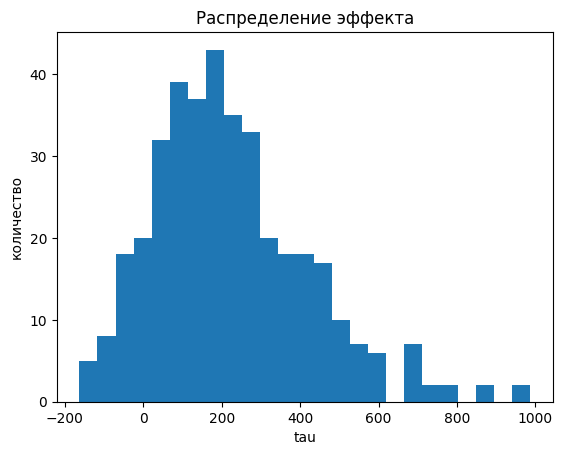

In [762]:
plt.figure()
plt.hist(tau_hat, bins=25)
plt.title("Распределение эффекта")
plt.xlabel("tau")
plt.ylabel("количество")
# plt.savefig("Распределение эффекта.png")
plt.show()

In [775]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_tau_trend_with_ci(
    X_test, X_cols, effects_test, feature,
    tau_col="tau", ci_low_col="ci_low", ci_high_col="ci_high",
    n_bins=10, by_value=False
):

    Xdf = pd.DataFrame(X_test, columns=X_cols)
    df = pd.concat([effects_test.reset_index(drop=True), Xdf.reset_index(drop=True)], axis=1)

    need = [feature, tau_col, ci_low_col, ci_high_col]
    d = df[need].dropna().copy()

    if by_value:
        g = d.groupby(feature, as_index=False).agg(
            x_mean=(feature, "mean"),
            tau_mean=(tau_col, "mean"),
            lo=(ci_low_col, "mean"),
            hi=(ci_high_col, "mean"),
            n=(tau_col, "size")
        ).sort_values("x_mean")
    else:
        d["bin"] = pd.qcut(d[feature], q=n_bins, duplicates="drop")
        g = d.groupby("bin", observed=True).agg(
            x_mean=(feature, "mean"),
            tau_mean=(tau_col, "mean"),
            lo=(ci_low_col, "mean"),
            hi=(ci_high_col, "mean"),
            n=(tau_col, "size")
        ).reset_index(drop=True).sort_values("x_mean")

    plt.figure(figsize=(7, 4))
    plt.plot(g["x_mean"], g["tau_mean"], marker="o")
    plt.fill_between(g["x_mean"], g["lo"], g["hi"], alpha=0.2)
    if feature == "size_of_firm":
        plt.xlim(0, 600)
    plt.title(f"{feature}: Средний эффект + ДИ")
    plt.xlabel(feature)
    plt.ylabel("Величина эффект")
    # plt.savefig(f"{feature}")
    plt.show()

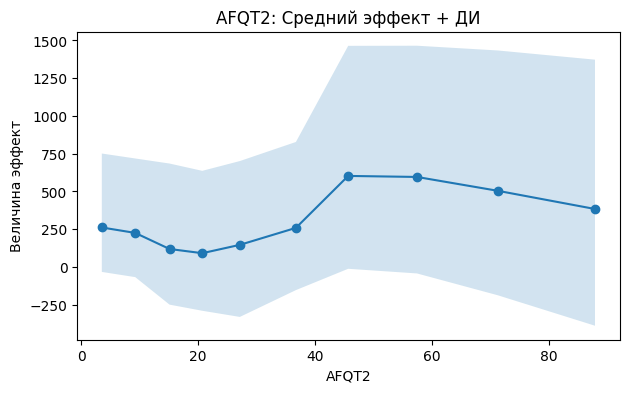

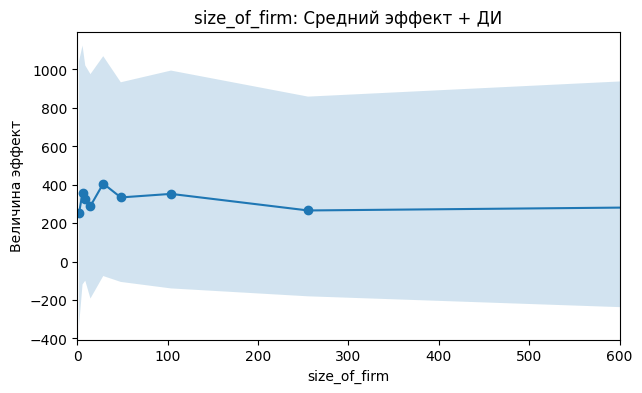

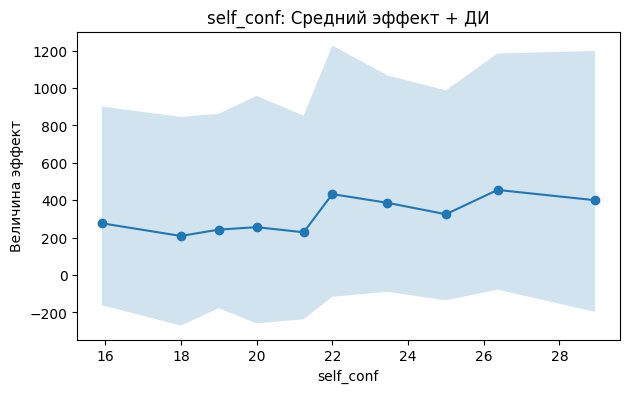

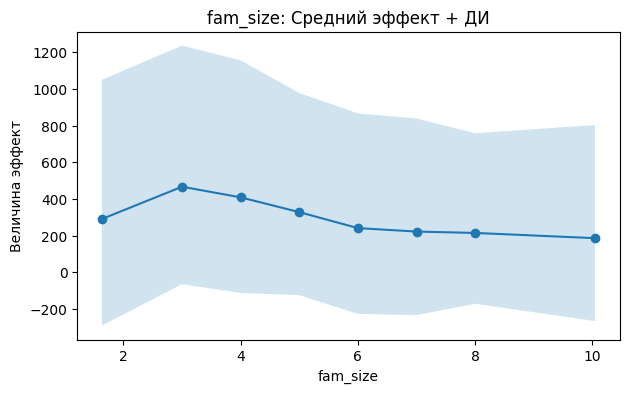

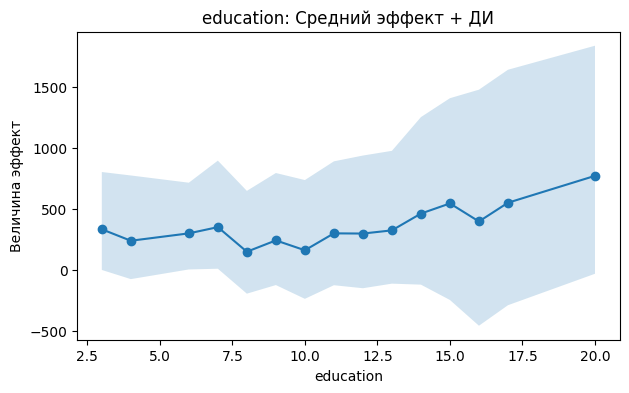

In [776]:
for f in ["AFQT2", "size_of_firm", "self_conf", "fam_size"]:
    plot_tau_trend_with_ci(X_test, X_cols, effects_test, f, n_bins=10, by_value=False)

plot_tau_trend_with_ci(X_test, X_cols, effects_test, "education", by_value=True)